<a href="https://colab.research.google.com/github/Bharatheesh-RB/HPC-For-AI/blob/main/HPC_for_AI_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%writefile vector_add.cu

// EXERCISE 1 - VECTOR ADDITION

#include <iostream>
#include <vector>
#include <chrono>
using namespace std;

__global__ void vectorAddGPU(const float *A, const float *B, float *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

void vectorAddCPU(const float *A, const float *B, float *C, int N) {
    for (int i = 0; i < N; i++) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    int sizes[] = {10000, 50000, 100000, 500000, 1000000, 5000000, 10000000};
    int num_sizes = 7;

    cout << "Size,CPU_Time_ms,GPU_Time_ms\n";

    for (int s = 0; s < num_sizes; s++) {
        int N = sizes[s];
        size_t bytes = N * sizeof(float);

        vector<float> h_A(N, 1.0f);
        vector<float> h_B(N, 2.0f);
        vector<float> h_C_CPU(N, 0.0f);
        vector<float> h_C_GPU(N, 0.0f);

        auto start_cpu = chrono::high_resolution_clock::now();
        vectorAddCPU(h_A.data(), h_B.data(), h_C_CPU.data(), N);
        auto end_cpu = chrono::high_resolution_clock::now();
        chrono::duration<float, milli> duration_cpu = end_cpu - start_cpu;

        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, bytes);
        cudaMalloc(&d_B, bytes);
        cudaMalloc(&d_C, bytes);

        auto start_gpu = chrono::high_resolution_clock::now();

        cudaMemcpy(d_A, h_A.data(), bytes, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B.data(), bytes, cudaMemcpyHostToDevice);

        int threadsPerBlock = 256;
        int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

        vectorAddGPU<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);
        cudaDeviceSynchronize();

        cudaMemcpy(h_C_GPU.data(), d_C, bytes, cudaMemcpyDeviceToHost);

        auto end_gpu = chrono::high_resolution_clock::now();
        chrono::duration<float, milli> duration_gpu = end_gpu - start_gpu;

        cout << N << "," << duration_cpu.count() << "," << duration_gpu.count() << "\n";

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    }
    return 0;
}

Overwriting vector_add.cu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


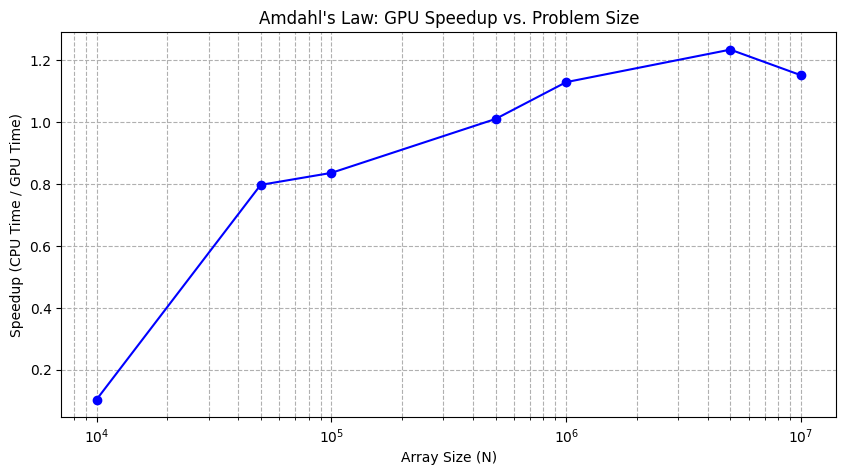

,Size,CPU_Time_ms,GPU_Time_ms,Speedup
0,10000,0.028935,0.280013,0.103334
1,50000,0.171771,0.215356,0.797614
2,100000,0.336452,0.402249,0.836427
3,500000,1.493620,1.477760,1.010732
4,1000000,3.002950,2.657820,1.129855
5,5000000,16.768200,13.578100,1.234945
6,10000000,30.386300,26.377300,1.151987


In [2]:
# Plotting the Amdahl's law
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Compile the CUDA code
!nvcc vector_add.cu -o vector_add

result = subprocess.run(['./vector_add'], stdout=subprocess.PIPE, text=True)
data = result.stdout

# Read data into Pandas DataFrame
df = pd.read_csv(StringIO(data))

# Calculate Speedup
df['Speedup'] = df['CPU_Time_ms'] / df['GPU_Time_ms']

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df['Size'], df['Speedup'], marker='o', linestyle='-', color='b')
plt.title("Amdahl's Law: GPU Speedup vs. Problem Size")
plt.xlabel("Array Size (N)")
plt.ylabel("Speedup (CPU Time / GPU Time)")
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.show()

display(df)

In [3]:
%%writefile matrix_mul.cu

// EXERCISE 2 - MATRIX MULTIPLICATION

#include <iostream>
#include <chrono>

using namespace std;

// CPU Logic for Matrix Multiplication
void matrixMulCPU(const float *A, const float *B, float *C, int N) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

__global__ void matrixMulGPU(const float *A, const float *B, float *C, int N) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main() {
    int N = 2048; // 2048x2048 matrix
    size_t bytes = N * N * sizeof(float);

    float *h_A = new float[N * N];
    float *h_B = new float[N * N];
    float *h_C_CPU = new float[N * N];
    float *h_C_GPU = new float[N * N];

    for (int i = 0; i < N * N; i++) {
        h_A[i] = 1.0f;
        h_B[i] = 2.0f;
        h_C_CPU[i] = 0.0f;
        h_C_GPU[i] = 0.0f;
    }

    cout << "Starting CPU Matrix Multiplication..." << endl;
    auto start_cpu = chrono::high_resolution_clock::now();

    matrixMulCPU(h_A, h_B, h_C_CPU, N);

    auto end_cpu = chrono::high_resolution_clock::now();
    chrono::duration<float, milli> duration_cpu = end_cpu - start_cpu;
    cout << "CPU Execution Time: " << duration_cpu.count() << " ms" << endl;

    cout << "\nStarting GPU Matrix Multiplication..." << endl;

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);

    cudaEvent_t start_total, stop_total;
    cudaEvent_t start_kernel, stop_kernel;
    cudaEventCreate(&start_total);
    cudaEventCreate(&stop_total);
    cudaEventCreate(&start_kernel);
    cudaEventCreate(&stop_kernel);

    dim3 threadsPerBlock(16, 16);
    dim3 blocksPerGrid((N + threadsPerBlock.x - 1) / threadsPerBlock.x,
                       (N + threadsPerBlock.y - 1) / threadsPerBlock.y);

    cudaEventRecord(start_total);

    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    cudaEventRecord(start_kernel);

    matrixMulGPU<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

    cudaEventRecord(stop_kernel);

    cudaMemcpy(h_C_GPU, d_C, bytes, cudaMemcpyDeviceToHost);

    cudaEventRecord(stop_total);

    cudaEventSynchronize(stop_total);

    float time_kernel = 0;
    float time_total = 0;
    cudaEventElapsedTime(&time_kernel, start_kernel, stop_kernel);
    cudaEventElapsedTime(&time_total, start_total, stop_total);

    cout << "GPU Kernel Execution Time (No memory transfers): " << time_kernel << " ms" << endl;
    cout << "GPU Total Time (With memory transfers): " << time_total << " ms" << endl;

    cout << "\nPerformance Comparison:" << endl;
    cout << "Speedup (CPU vs GPU Kernel Only): " << duration_cpu.count() / time_kernel << "x" << endl;
    cout << "Speedup (CPU vs GPU Total): " << duration_cpu.count() / time_total << "x" << endl;

    cout << "\nVerification:" << endl;
    cout << "Value of C_CPU[0] = " << h_C_CPU[0] << endl;
    cout << "Value of C_GPU[0] = " << h_C_GPU[0] << " (Expected: " << N * 2.0f << ")" << endl;

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    cudaEventDestroy(start_total);
    cudaEventDestroy(stop_total);
    cudaEventDestroy(start_kernel);
    cudaEventDestroy(stop_kernel);

    delete[] h_A; delete[] h_B; delete[] h_C_CPU; delete[] h_C_GPU;

    return 0;
}

Overwriting matrix_mul.cu


In [4]:
!nvcc matrix_mul.cu -o matrix_mul
!./matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Starting CPU Matrix Multiplication...
CPU Execution Time: 177277 ms

Starting GPU Matrix Multiplication...
GPU Kernel Execution Time (No memory transfers): 44.0084 ms
GPU Total Time (With memory transfers): 56.8046 ms

Performance Comparison:
Speedup (CPU vs GPU Kernel Only): 4028.25x
Speedup (CPU vs GPU Total): 3120.81x

Verification:
Value of C_CPU[0] = 4096
Value of C_GPU[0] = 4096 (Expected: 4096)
